<a href="https://colab.research.google.com/github/sitarabrent/MD-PS02-SC/blob/master/Optics_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Code For Optics Lab
Maggie Stevens


Import statements

# New Section

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Defining Functions

In [ ]:
def x_avg(x_left_list, x_right_list):
    x_avg_list = []
    for i in range(len(x_right_list)):
      if x_right_list[i] != x_left_list[i]:
        x_avg = (np.abs(x_left_list[i] + x_right_list[i])) / 2
        x_avg_list.append(x_avg)
      else:
        x_avg_list.append(x_right_list[i])
    return x_avg_list

def avg(val, val_2):
    return (val + val_2) / 2

def graph(x_list, y_list, color, grating):
    if color == 1:
        color_str = "Blue"
    elif color == 0:
        color_str = "Red"
    else:
        return "Warning, Invalid Color"
    y = np.array(y_list)
    x = np.array(x_list)

    plt.errorbar(x, y, xerr = 0.1, yerr = 0.1, fmt = 'o', capsize = 5, color = color_str)
    coefficients, covariance_matrix = np.polyfit(x, y, 1, cov=True)
    m = coefficients[0]
    slope_uncertainty = np.sqrt(covariance_matrix[0, 0])
    b = coefficients[1]
    plt.plot(x, m * x, color = color_str, label=f'y = {m:.4f}x')

    plt.legend()
    plt.title(f"Average Distance Between the Central Max and the First Order Fringes vs\nLength from Diffraction Grating to Screen\nfor a {color_str} laser with {grating} lines / mm grating")
    plt.ylabel("Distance to 1st Order Fringe (cm)")
    plt.xlabel("Length to Screen (cm)")
    return m, b, slope_uncertainty

def get_slope(x_list, y_list):
    y = np.array(y_list)
    x = np.array(x_list)

    coefficients, covariance_matrix = np.polyfit(x, y, 1, cov=True)
    m = coefficients[0]
    slope_uncertainty = np.sqrt(covariance_matrix[0, 0])
    b = coefficients[1]
    return m, slope_uncertainty, b

def get_wave(grating, slope):
    grating = grating * 10
    wavelength = ((1/(grating)) * slope) / (1 + (slope) ** 2) ** (1 / 2)
    wavelength = wavelength * (10 ** 7)
    return wavelength

def get_error(wave_1, true_val):
    error = np.abs(true_val - wave_1) / true_val
    percent_err = error * 100
    return percent_err

def get_data_frame(length, x_left, x_right):
  df = pd.DataFrame(
    {
     "Length from Screen": length,
     "X Left": x_left,
     "X Center": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     "X Right": x_right,
    }
  )
  return df

Data

In [ ]:
length_0_0 = [10.4, 15.4, 20.4, 25.4, 30.4, 35.4, 40.4, 45.4, 50.4, 55.4] # Used for the first day of data. There was a 4 mm gap between the rulers
length = [10.2, 15.2, 20.2, 25.2, 30.2, 35.2, 40.2, 45.2, 50.2, 55.2] # Red Laser uses this because there was a gap between the rulers
length_1 = [10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0]
x_max = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0,]
color = [0, 1]
grating = [500, 1000]

Graph Red 500 nm

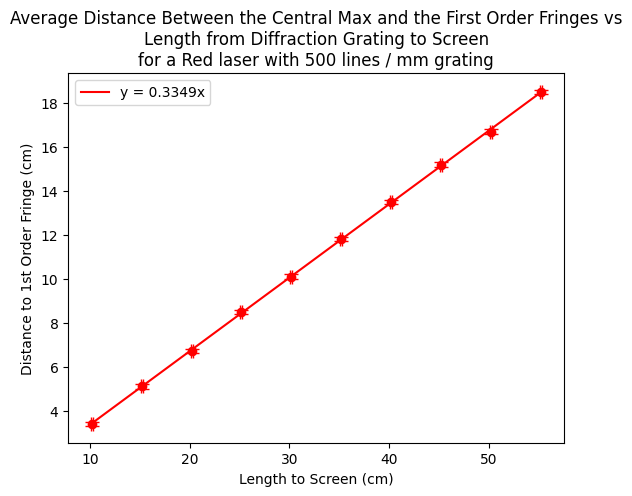

Calculated Wavelength: 635.14 nm


In [ ]:
## Graph for Red, 500 lines/mm
# x_left_0_0 = [3.6, 5.3, 6.9, 8.6, 10.3, 12.1, 13.8, 15.5, 17.1, 19]
# x_right_0_0 = [3.7, 5.3, 6.9, 8.6, 10.3, 12.1, 13.8, 15.5, 17.2, 19]
x_left_0_0 = [3.4, 5.1, 6.7, 8.5, 10.1, 11.8, 13.5, 15.2, 16.7, 18.5]
x_right_0_0 = [3.4, 5.1, 6.7, 8.5, 10.1, 11.8, 13.5, 15.2, 16.7, 18.5]
x_avg_0_0 = x_avg(x_left_0_0, x_right_0_0)
graph_0_0 = graph(length, x_avg_0_0, color[0], grating[0])
slope_0_0, uncert_0_0, int_0_0 = get_slope(length, x_avg_0_0)
plt.show(graph_0_0)

wavelen_0_0 = get_wave(grating[0], slope_0_0)
print(f"Calculated Wavelength: {wavelen_0_0:.2f} nm")

Graph Red 1000 nm

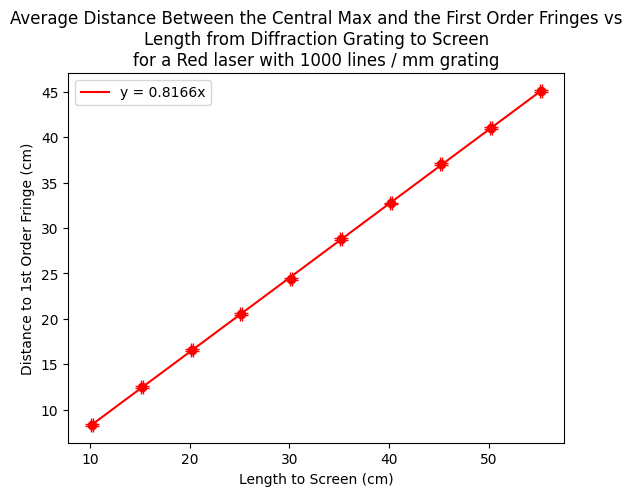

Calculated Wavelength: 632.51 nm


In [ ]:
## Graph for Red, 1000 lines/mm
# x_left_0_1 = [8.8, 13.1, 17.1, 21.0, 25.5, 29.9, 34.0, 38.5, 42.7, 47.6]
# x_right_0_1 = [8.9, 13.2, 17.1, 21.0, 25.5, 29.9, 35.0, 38.5, 42.7, 47.6]
x_left_0_1 = [8.3, 12.5, 16.6, 20.5, 24.4, 28.8, 32.7, 37.0, 41.0, 45.1] #Day 2
x_right_0_1 = [8.3, 12.5, 16.6, 20.5, 24.4, 28.8, 32.7, 37.0, 41.0, 45.1] #Day 2
x_avg_0_1 = x_avg(x_left_0_1, x_right_0_1)
graph_0_1 = graph(length, x_avg_0_1, color[0], grating[1])
slope_0_1, uncert_0_1, int_0_1 = get_slope(length, x_avg_0_1)
plt.show(graph_0_1)

wavelen_0_1 = get_wave(grating[1], slope_0_1)
print(f"Calculated Wavelength: {wavelen_0_1:.2f} nm")

Graph Blue 500 nm

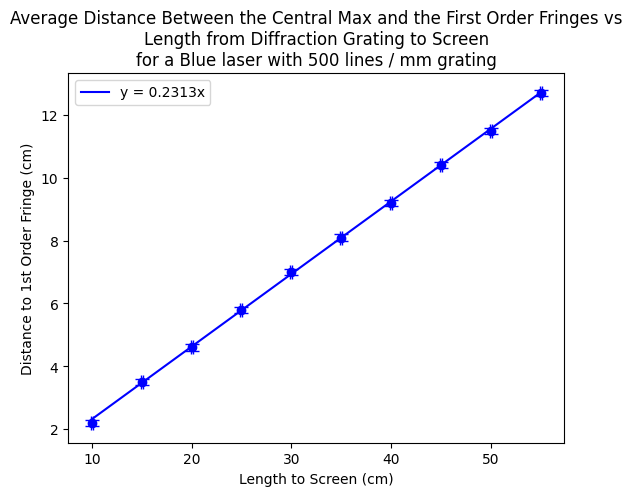

Calculated Wavelength: 450.65 nm


In [ ]:
# ## Graph for Blue, 500 lines/mm
# x_left_1_0 = [2.4, 3.7, 4.6, 5.8, 6.9, 8.0, 9.2, 10.3, 11.4, 12.4]
# x_right_1_0 = [2.4, 3.6, 4.6, 5.8, 6.9, 8.0, 9.1, 10.3, 11.2, 12.5]
x_left_1_0 = [2.2, 3.5, 4.6, 5.8, 7.0, 8.1, 9.2, 10.4, 11.5, 12.7] #Day 2
x_right_1_0 = [2.2, 3.5, 4.6, 5.8, 7.0, 8.1, 9.2, 10.4, 11.5, 12.7] # Day 2
x_avg_1_0 = x_avg(x_left_1_0, x_right_1_0)
graph_1_0 = graph(length_1, x_avg_1_0, color[1], grating[0])
slope_1_0, uncert_1_0, int_1_0 = get_slope(length_1, x_avg_1_0)
plt.show(graph_1_0)

wavelen_1_0 = get_wave(grating[0], slope_1_0)
print(f"Calculated Wavelength: {wavelen_1_0:.2f} nm")

Graph Blue 1000 nm

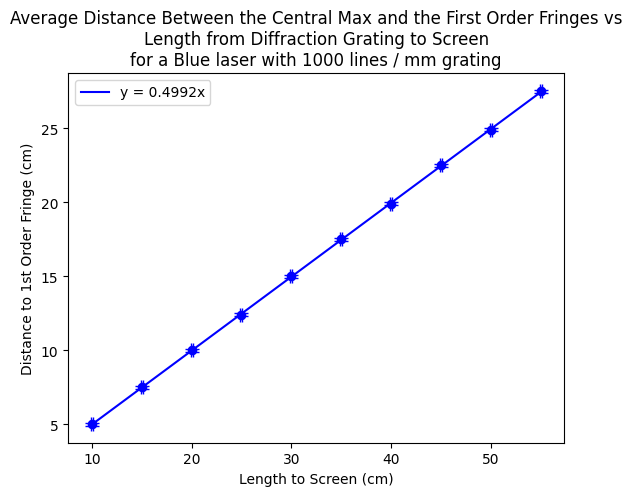

Calculated Wavelength: 446.61 nm


In [ ]:
## Graph for Blue, 1000 lines/mm
# x_left_1_1 = [5.4, 7.5, 10.0, 12.5, 15.1, 17.6, 20.1, 22.5, 24.9, 27.3]
# x_right_1_1 = [5.4, 7.5, 10.0, 12.6, 15.1, 17.6, 20.2, 22.6, 24.9, 27.3]
x_left_1_1 = [5.0, 7.5, 10.0, 12.4, 15.0, 17.5, 19.9, 22.5, 24.9, 27.5] # Day 2
x_right_1_1 = [5.0, 7.5, 10.0, 12.4, 15.0, 17.5, 19.9, 22.5, 24.9, 27.5] # Day 2
x_avg_1_1 = x_avg(x_left_1_1, x_right_1_1)
graph_1_1 = graph(length_1, x_avg_1_1, color[1], grating[1])
slope_1_1, uncert_1_1, int_1_1 = get_slope(length_1, x_avg_1_1)
plt.show(graph_1_1)

wavelen_1_1 = get_wave(grating[1], slope_1_1)
print(f"Calculated Wavelength: {wavelen_1_1:.2f} nm")

Calculating Error

In [ ]:
true_red = 653 # nm
true_blue = 450 # nm

avg_blue = avg(wavelen_1_0, wavelen_1_1)
avg_red = avg(wavelen_0_0, wavelen_0_1)

red_err = get_error(avg_red, true_red)
blue_err = get_error(avg_blue, true_blue)

print("Percent Error for Red Laser:", red_err)
print("Percent Error for Blue Laser:", blue_err)

Percent Error for Red Laser: 2.9363826331617684
Percent Error for Blue Laser: 0.30482079271918233


Data Frames with the Data so that it looks pretty :)

In [ ]:
print("Data for Red Laser, 500 lines/mm")
df_0_0 = get_data_frame(length, x_left_0_0, x_right_0_0)
df_0_0.head(10)

Data for Red Laser, 500 lines/mm


,Length from Screen,X Left,X Center,X Right
0,10.2,3.4,0,3.4
1,15.2,5.1,0,5.1
2,20.2,6.7,0,6.7
3,25.2,8.5,0,8.5
4,30.2,10.1,0,10.1
5,35.2,11.8,0,11.8
6,40.2,13.5,0,13.5
7,45.2,15.2,0,15.2
8,50.2,16.7,0,16.7
9,55.2,18.5,0,18.5


In [ ]:
print("Data for Red Laser, 1000 lines/mm")
df_0_1 = get_data_frame(length, x_left_0_1, x_right_0_1)
df_0_1.head(10)

Data for Red Laser, 1000 lines/mm


,Length from Screen,X Left,X Center,X Right
0,10.2,8.3,0,8.3
1,15.2,12.5,0,12.5
2,20.2,16.6,0,16.6
3,25.2,20.5,0,20.5
4,30.2,24.4,0,24.4
5,35.2,28.8,0,28.8
6,40.2,32.7,0,32.7
7,45.2,37.0,0,37.0
8,50.2,41.0,0,41.0
9,55.2,45.1,0,45.1


In [ ]:
print("Data for Blue Laser, 500 lines/mm")
df_1_0 = get_data_frame(length_1, x_left_1_0, x_right_1_0)
df_1_0.head(10)

Data for Blue Laser, 500 lines/mm


,Length from Screen,X Left,X Center,X Right
0,10.0,2.2,0,2.2
1,15.0,3.5,0,3.5
2,20.0,4.6,0,4.6
3,25.0,5.8,0,5.8
4,30.0,7.0,0,7.0
5,35.0,8.1,0,8.1
6,40.0,9.2,0,9.2
7,45.0,10.4,0,10.4
8,50.0,11.5,0,11.5
9,55.0,12.7,0,12.7


In [ ]:
print("Data for Blue Laser, 1000 lines/mm")
df_1_1 = get_data_frame(length_1, x_left_1_1, x_right_1_1)
df_1_1.head(10)

Data for Blue Laser, 1000 lines/mm


,Length from Screen,X Left,X Center,X Right
0,10.0,5.0,0,5.0
1,15.0,7.5,0,7.5
2,20.0,10.0,0,10.0
3,25.0,12.4,0,12.4
4,30.0,15.0,0,15.0
5,35.0,17.5,0,17.5
6,40.0,19.9,0,19.9
7,45.0,22.5,0,22.5
8,50.0,24.9,0,24.9
9,55.0,27.5,0,27.5
